In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
wt_df = pd.read_csv('data/data_sources_silver/wiki_and_trends_20260528.csv')
joined_bgg_df = pd.read_csv('data/data_sources_silver/bgg_and_marketplace_20260528.csv')

### Check trends for select few games after winning awards

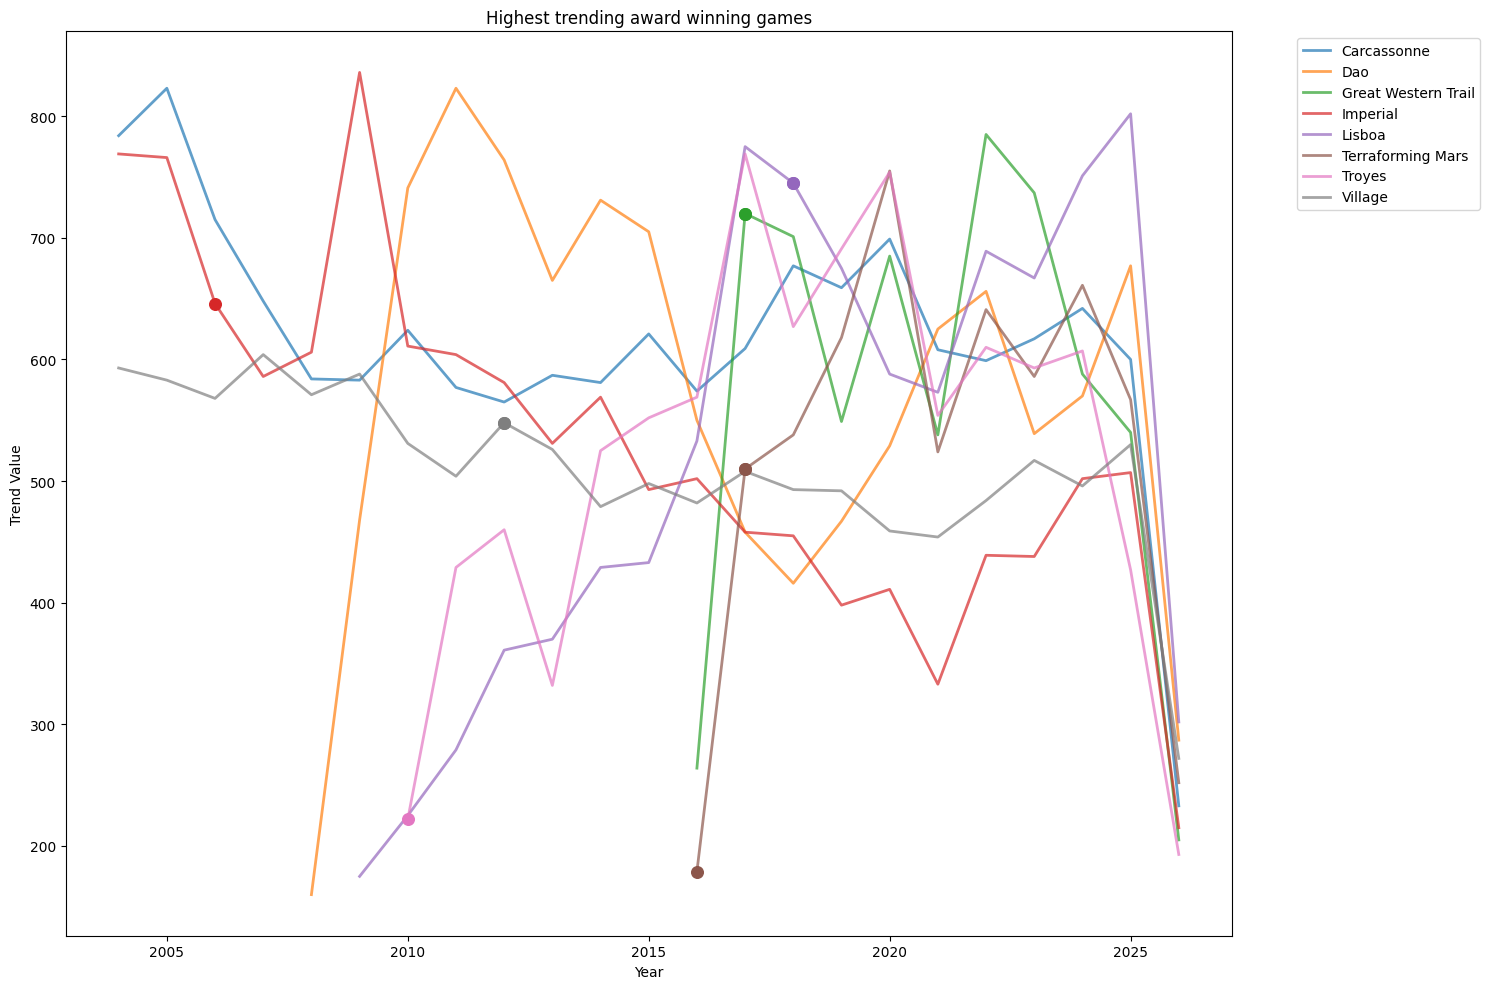

In [3]:
#Not seeing a ton of value here, but its nice to check!
#some items trend upwards after winninng an award and others trend downwards.
#2026 obviously drops off because the year was only about half way over when the data was
#cached
plt.figure(figsize=(15, 10))

top_games = wt_df.groupby('game_name')['trend_value'].mean().sort_values(ascending=False).head(8).index
df_top = wt_df[wt_df['game_name'].isin(top_games)]
df_top = df_top.sort_values(['game_name', 'award_year'])


df_award_games = wt_df.groupby('game_name').filter(
    lambda x: x['award'].notna().any()
)

for game, g in df_top.groupby('game_name'):
    line, = plt.plot(
        g['award_year'],
        g['trend_value'],
        alpha=0.7,
        linewidth=2,
        label=game
    )

    g_awards = g[g['award'].notna()]
    
    plt.scatter(
        g_awards['award_year'],
        g_awards['trend_value'],
        color=line.get_color(),
        s=70,
        zorder=5
    )

plt.xlabel('Year')
plt.ylabel('Trend Value')
plt.title('Highest trending award winning games')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Raw price distributions for top games by bayes\_rating

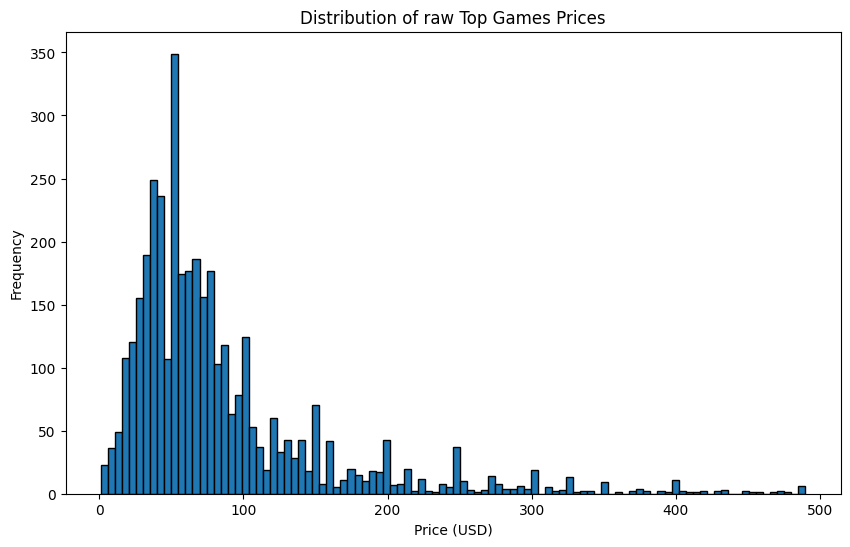

In [4]:
#The bayes_rating is pretty close to the proprietary "geek rating"
#so sorting records by it should get us close enough to the BGG's ranking of products.
#the number of games in the distribution can be adjusted by altering the number in the 
#.nlargest arguement
top_games = (
    joined_bgg_df
    .groupby('game_name', as_index=False)['bayes_rating']
    .max()
    .nlargest(50, 'bayes_rating')
    .set_index('game_name')['bayes_rating']
)

top_df = joined_bgg_df[joined_bgg_df['game_name'].isin(top_games.index)]

plt.figure(figsize=(10, 6))
plt.hist(top_df['price_usd'], bins=100, edgecolor='black')
plt.title('Distribution of raw Top Games Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

### Data work on wiki\_trends df to get before and after deltas

In [5]:
#find only years where an award was won
award_df = wt_df[wt_df['award'].notna()].merge(
    wt_df,
    on='game_name',
    suffixes=('_event', '_all')
)

#delinieate periods of time befor, after, and when an award was won
award_df['period'] = np.where(
    award_df['award_year_all'] < award_df['award_year_event'], 'before',
    np.where(
        award_df['award_year_all'] > award_df['award_year_event'], 'after',
        'event'
    )
)

#restack dataframe to give us delta score for award publications
event_df = (
    award_df[award_df['period'] != 'event']
    .groupby([
        'game_name',
        'award_event',
        'category_event',
        'award_year_event',
        'period'
    ])['trend_value_all']
    .mean()
    .unstack('period')
    .reset_index()
)
event_df = event_df.fillna(0)
event_df['delta'] = event_df['after'] - event_df['before']

### Most impactful publications on Trend data

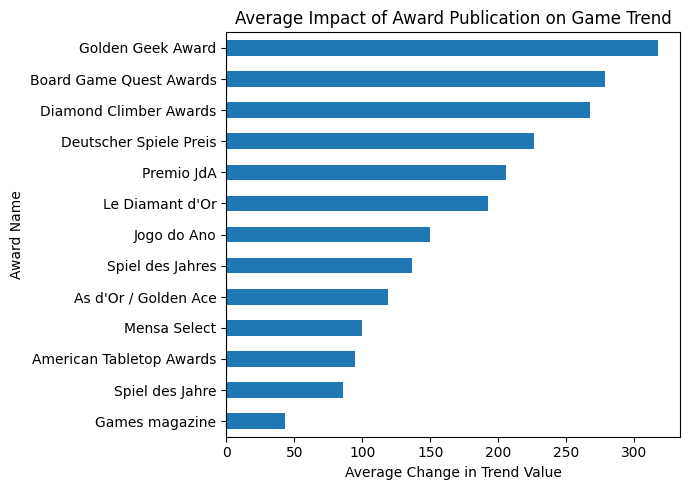

In [13]:
#cleaned up the golden geek award. weird that wikipedia seperates them
event_df['award_event'] = event_df['award_event'].replace('Golden Geek Award (Till 2019)', 'Golden Geek Award')
event_df['award_event'] = event_df['award_event'].replace('Golden Geek Award (2020 onwards)', 'Golden Geek Award')
publication_df = event_df.groupby('award_event')['delta'].mean()
publication_df = publication_df.sort_values()

#plot
ax = publication_df.plot.barh(
    x='award_event',
    y='delta',
    figsize=(7, 5),
    legend=False
)
plt.title('Average Impact of Award Publication on Game Trend')
plt.xlabel('Average Change in Trend Value')
plt.ylabel('Award Name')
plt.axvline(0)

plt.tight_layout()
plt.savefig('Figures/Award_Trends_Impact.jpg')
plt.show()

### Most impacted games after winning

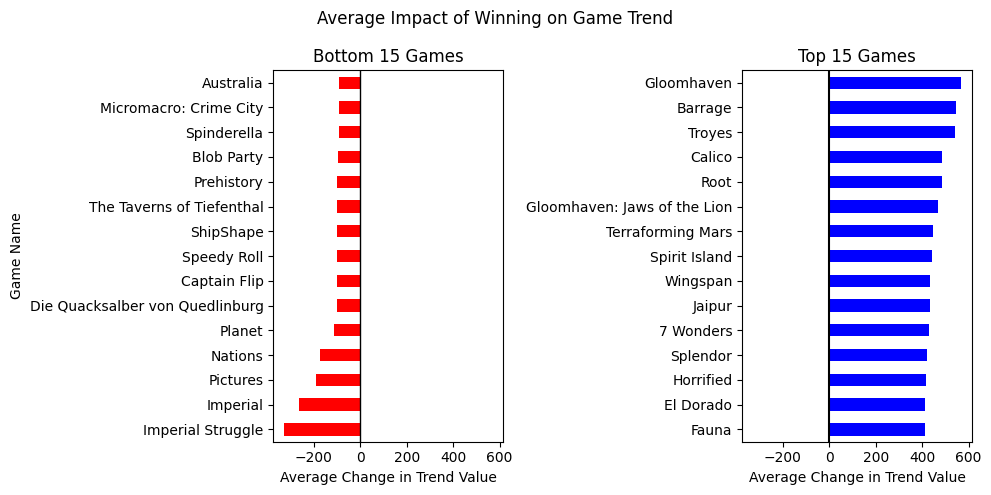

In [7]:
game_df = event_df.groupby('game_name')['delta'].mean().sort_values()
bottom = game_df.head(15)
top = game_df.tail(15)

#plot
fig, axes = plt.subplots(ncols=2, figsize=(10, 5), sharex=True)
#left plot
bottom.plot.barh(
    ax=axes[0],
    color='red',
    legend=False
)
axes[0].set_title('Bottom 15 Games')
axes[0].set_xlabel('Average Change in Trend Value')
axes[0].set_ylabel('Game Name')
axes[0].axvline(0, color='black', linewidth=1)

#right plot
top.plot.barh(
    ax=axes[1],
    color='blue',
    legend=False
)
axes[1].set_title('Top 15 Games')
axes[1].set_xlabel('Average Change in Trend Value')
axes[1].set_ylabel('')
axes[1].axvline(0, color='black')

fig.suptitle('Average Impact of Winning on Game Trend')
plt.tight_layout()
plt.show()
fig.savefig('Figures/Game_Trends_Impact.jpg')